# 🛡️ AI Payroll Guardian — Exploratory Data Analysis (Phase 1)
**Project**: AI Payroll Guardian  
**Phase**: Phase 1 — Data Foundation & Anomaly Profile Analysis  
**Goal**: Comprehensively audit and visualize the synthetic clean dataset, injected payroll anomalies, attendance and deduction distributions, and feature engineering foundations.

---
### 📌 Scope of Analysis
1. **Dataset Dimensions & Schema Integrity**
2. **Missing Values & Duplicate Audit**
3. **Salary Distributions Overview (Basic, Allowances, Gross, Net)**
4. **Departmental Salary Dynamics**
5. **Designation Hierarchy & Salary Progression**
6. **Overtime Intensity & Departmental Patterns**
7. **Attendance & Leave Distributions**
8. **Bonus Structures & Appraisal Seasonality**
9. **Statutory & Other Deductions Breakdown (PF, ESI, TDS, PT)**
10. **Reconciliation Audit (Gross, Deductions, Net)**
11. **Month-over-Month (MoM) Dynamics & Legitimate Increments**
12. **Anomaly Distribution & Class Balance**
13. **Analysis of 13 Injected Anomaly Types by Severity**
14. **Comparative Case Studies: Normal vs Anomalous Employee History**
15. **Key Takeaways & Readiness for Phase 2 ML Modeling**


## 1. Environment Setup & Data Ingestion
Load libraries, configure plotting aesthetics, and read the clean, anomalous, and audit metadata datasets.


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting style configuration
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Paths
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SYNTHETIC_DIR = ROOT_DIR / "data" / "synthetic"

clean_path = SYNTHETIC_DIR / "clean_payroll.csv"
anom_path = SYNTHETIC_DIR / "anomalous_payroll.csv"
meta_path = SYNTHETIC_DIR / "anomaly_metadata.csv"

df_clean = pd.read_csv(clean_path)
df_anom = pd.read_csv(anom_path)
df_meta = pd.read_csv(meta_path)

print(f"Clean Dataset Shape     : {df_clean.shape}")
print(f"Anomalous Dataset Shape : {df_anom.shape}")
print(f"Anomaly Metadata Shape  : {df_meta.shape}")


Clean Dataset Shape     : (120000, 24)
Anomalous Dataset Shape : (120462, 24)
Anomaly Metadata Shape  : (6000, 8)


## 2. Dataset Dimensions & Schema Audit
Verify the presence of mandatory columns, unique employee counts, and multi-month timeline coverage.


In [2]:
print("--- Clean Dataset Summary ---")
display(df_clean.info())

print(f"Unique Employees: {df_clean['employee_id'].nunique():,}")
print(f"Unique Months   : {df_clean['payroll_month'].nunique()} ({df_clean['payroll_month'].min()} to {df_clean['payroll_month'].max()})")
print(f"Departments     : {df_clean['department'].unique().tolist()}")
print(f"Designations    : {df_clean['designation'].unique().tolist()}")


--- Clean Dataset Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   employee_id        120000 non-null  object 
 1   payroll_month      120000 non-null  object 
 2   department         120000 non-null  object 
 3   designation        120000 non-null  object 
 4   joining_date       120000 non-null  object 
 5   employment_status  120000 non-null  object 
 6   location           120000 non-null  object 
 7   working_days       120000 non-null  int64  
 8   present_days       120000 non-null  int64  
 9   leave_days         120000 non-null  int64  
 10  basic_salary       120000 non-null  float64
 11  allowances         120000 non-null  float64
 12  overtime_hours     120000 non-null  float64
 13  overtime_amount    120000 non-null  float64
 14  bonus              120000 non-null  float64
 15  gross_salary       12

None

## 3. Missing Values & Duplicate Records Check
Check data completeness and demonstrate how duplicates were created in the anomalous dataset.


In [3]:
null_clean = df_clean.isnull().sum()
null_anom = df_anom.isnull().sum()

clean_dups = df_clean.duplicated(subset=['employee_id', 'payroll_month']).sum()
anom_dups = df_anom.duplicated(subset=['employee_id', 'payroll_month']).sum()

summary_audit = pd.DataFrame({
    "Clean Null Count": null_clean,
    "Anomalous Null Count": null_anom
})
print("Missing values per column:")
display(summary_audit)

print(f"\nDuplicate (Employee, Month) pairs in Clean Data     : {clean_dups}")
print(f"Duplicate (Employee, Month) pairs in Anomalous Data : {anom_dups} (Intentionally injected DUPLICATE_EMPLOYEE_RECORD anomalies)")


Missing values per column:
Duplicate (Employee, Month) pairs in Clean Data     : 0
Duplicate (Employee, Month) pairs in Anomalous Data : 923 (Intentionally injected DUPLICATE_EMPLOYEE_RECORD anomalies)


,Clean Null Count,Anomalous Null Count
employee_id,0,0
payroll_month,0,0
department,0,0
designation,0,0
joining_date,0,0
employment_status,0,0
location,0,0
working_days,0,0
present_days,0,0
leave_days,0,0


## 4. Overall Salary Distributions (Clean Dataset)
Examine the distribution of basic salary, allowances, gross salary, and net salary.


,count,mean,std,min,25%,50%,75%,max
basic_salary,120000.0,43353.538621,38383.896679,6750.0,18182.94,30586.08,53679.7800,323753.16
allowances,120000.0,52987.658228,46913.651577,8250.0,22223.60,37382.99,65608.6200,395698.31
gross_salary,120000.0,97981.367277,86362.095459,15000.0,41294.41,69384.63,121441.2275,860259.55
net_salary,120000.0,83967.753482,67235.576183,13877.5,38100.54,62714.88,105779.9125,666243.15


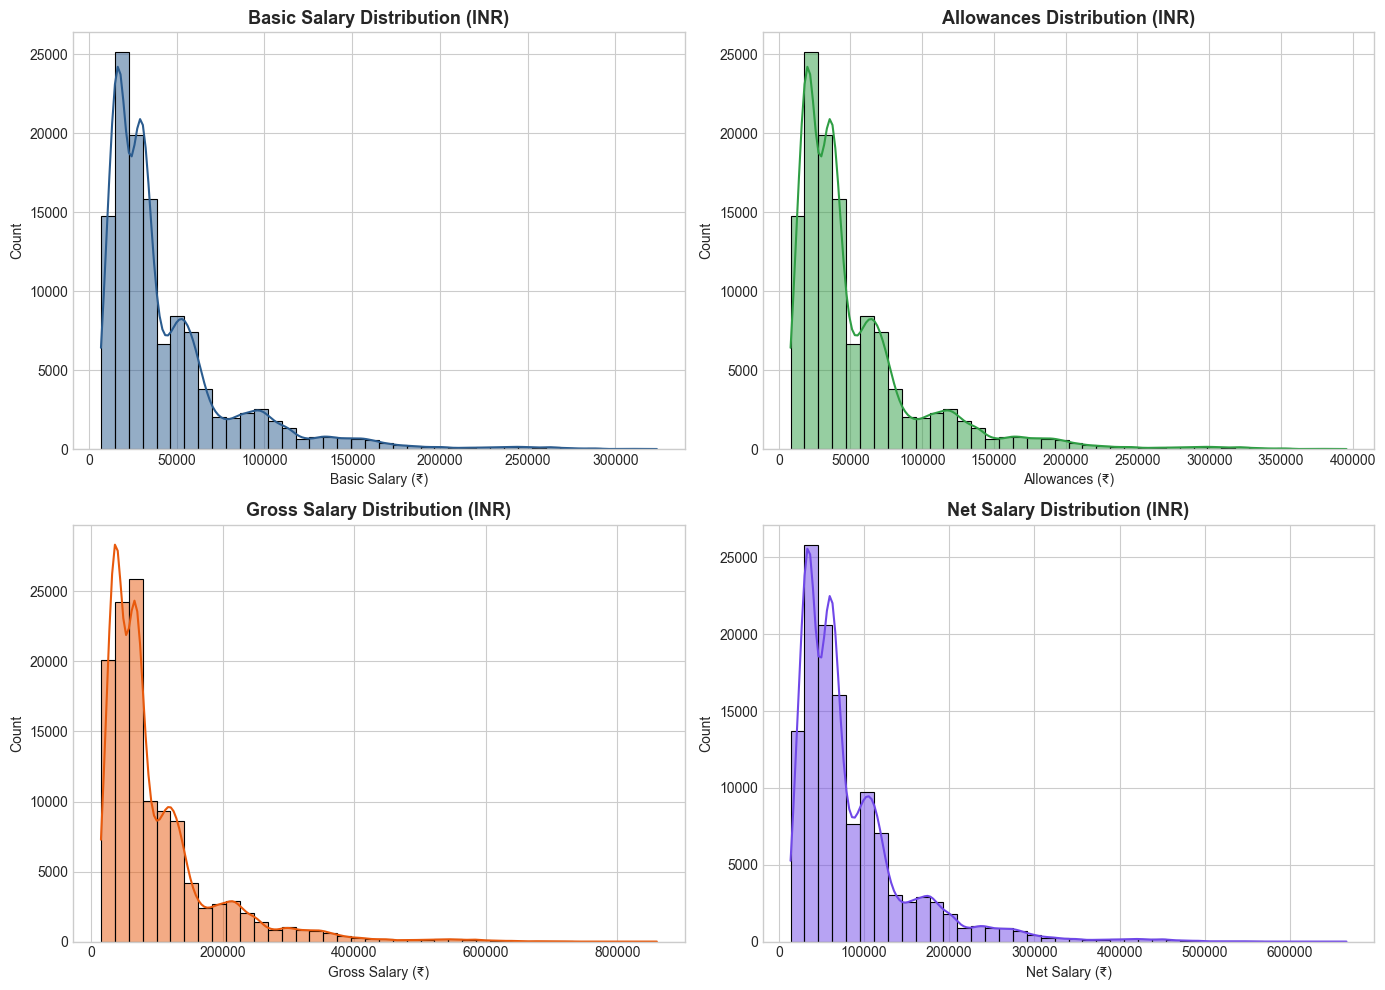

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_clean["basic_salary"], kde=True, ax=axes[0, 0], color="#2b5c8f", bins=40)
axes[0, 0].set_title("Basic Salary Distribution (INR)")
axes[0, 0].set_xlabel("Basic Salary (₹)")

sns.histplot(df_clean["allowances"], kde=True, ax=axes[0, 1], color="#2f9e44", bins=40)
axes[0, 1].set_title("Allowances Distribution (INR)")
axes[0, 1].set_xlabel("Allowances (₹)")

sns.histplot(df_clean["gross_salary"], kde=True, ax=axes[1, 0], color="#e8590c", bins=40)
axes[1, 0].set_title("Gross Salary Distribution (INR)")
axes[1, 0].set_xlabel("Gross Salary (₹)")

sns.histplot(df_clean["net_salary"], kde=True, ax=axes[1, 1], color="#7048e8", bins=40)
axes[1, 1].set_title("Net Salary Distribution (INR)")
axes[1, 1].set_xlabel("Net Salary (₹)")

plt.tight_layout()
plt.show()

display(df_clean[["basic_salary", "allowances", "gross_salary", "net_salary"]].describe().T)


## 5. Salary Distribution by Department
Analyze the salary variability and compensation tiers across different business units.


,count,mean,median,std,min,max
department,,,,,,
Administration,4788,70582.58,56255.16,51903.52,16169.40,354708.89
Engineering,36516,137041.93,107100.93,111436.81,22482.62,860259.55
Finance,7056,102680.29,79331.25,88935.93,20000.00,583999.91
HR,5856,79101.73,63496.52,61755.88,16605.78,442332.81
Marketing,9408,85665.14,67366.74,67632.98,18167.66,481663.51
Operations,23664,78458.91,63611.88,60315.01,16000.00,423220.07
Sales,18336,86823.40,68156.30,72818.01,18000.00,568853.50
Support,14376,67701.48,54877.66,50548.30,15000.00,365367.50


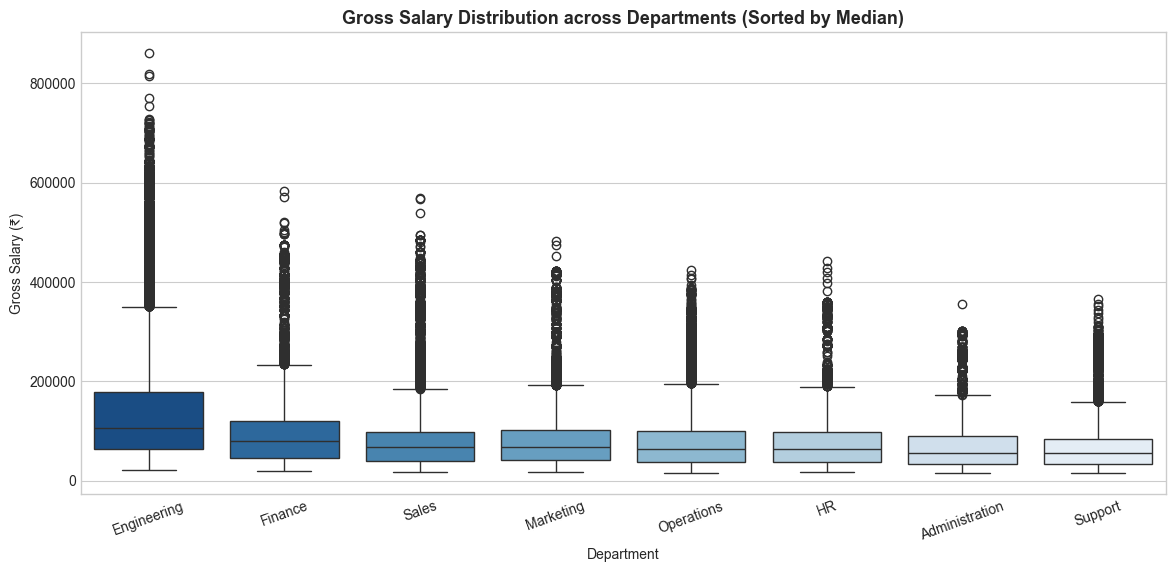

In [5]:
plt.figure(figsize=(14, 6))
dept_order = df_clean.groupby("department")["gross_salary"].median().sort_values(ascending=False).index

sns.boxplot(data=df_clean, x="department", y="gross_salary", order=dept_order, palette="Blues_r")
plt.title("Gross Salary Distribution across Departments (Sorted by Median)")
plt.xlabel("Department")
plt.ylabel("Gross Salary (₹)")
plt.xticks(rotation=20)
plt.show()

dept_stats = df_clean.groupby("department")["gross_salary"].agg(["count", "mean", "median", "std", "min", "max"]).round(2)
display(dept_stats)


## 6. Designation Hierarchy & Salary Tiers
Verify that compensation strictly reflects the career ladder: `Intern < Junior < Mid-level < Senior < Manager < Director`.


,count,mean,median,std,min,max
designation,,,,,,
Intern,11286,24987.26,24015.00,4821.93,15000.00,49136.55
Junior,41013,47104.00,42566.38,13445.25,22046.10,105249.25
Mid-level,36416,86533.08,78204.84,26081.30,35472.41,202976.32
Senior,18665,151927.58,136292.07,49542.71,63301.29,363790.09
Manager,8930,237308.99,217430.02,73313.14,109646.19,514471.78
Director,3690,389646.42,357505.94,123331.09,181650.70,860259.55


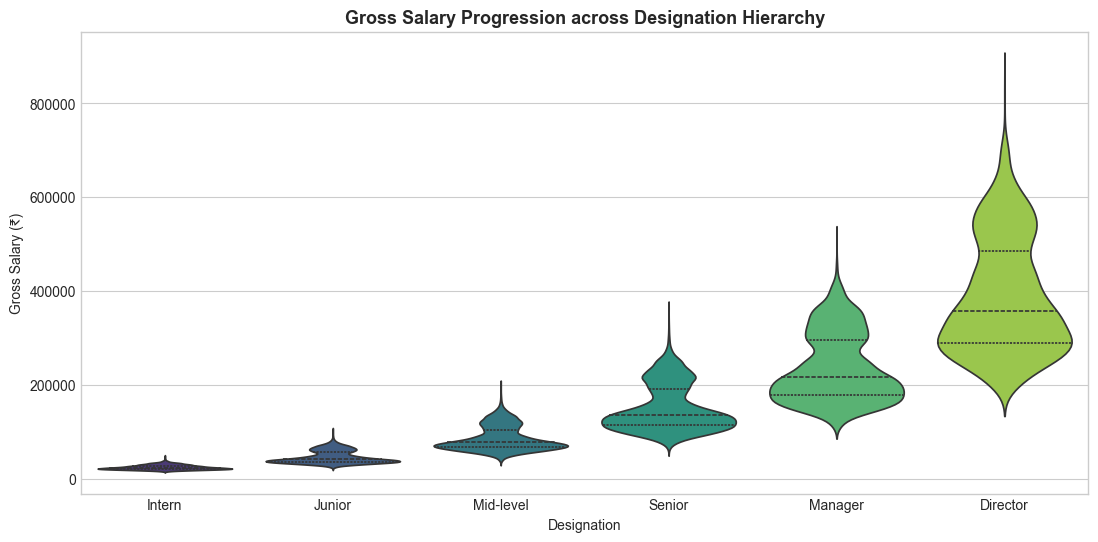

In [6]:
desig_order = ["Intern", "Junior", "Mid-level", "Senior", "Manager", "Director"]

plt.figure(figsize=(13, 6))
sns.violinplot(data=df_clean, x="designation", y="gross_salary", order=desig_order, palette="viridis", inner="quartile")
plt.title("Gross Salary Progression across Designation Hierarchy")
plt.xlabel("Designation")
plt.ylabel("Gross Salary (₹)")
plt.show()

desig_summary = df_clean.groupby("designation")["gross_salary"].agg(["count", "mean", "median", "std", "min", "max"]).reindex(desig_order).round(2)
display(desig_summary)


## 7. Overtime Hours & Department Intensity
Analyze overtime distribution in clean vs anomalous data. In clean data, overtime is bounded to realistic hours for operational roles.


Clean Overtime Statistics (where OT > 0):


count    30089.00
mean         9.98
std          6.17
min          2.00
25%          5.30
50%          8.70
75%         13.20
max         32.00

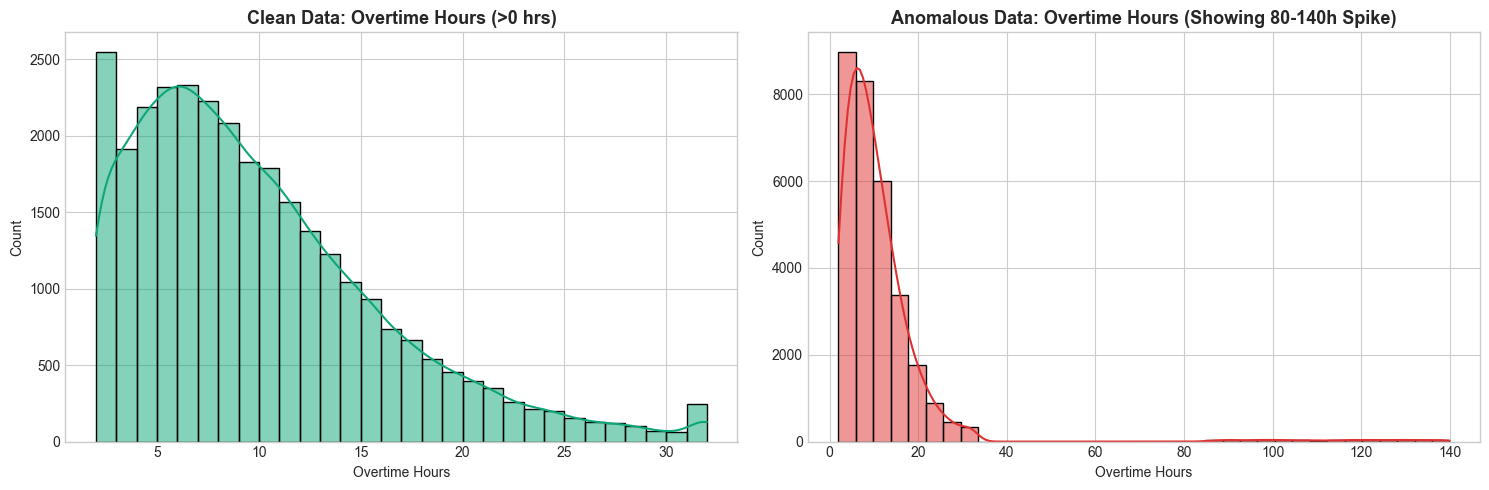

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Clean OT
sns.histplot(df_clean[df_clean["overtime_hours"] > 0]["overtime_hours"], bins=30, kde=True, ax=axes[0], color="#0ca678")
axes[0].set_title("Clean Data: Overtime Hours (>0 hrs)")
axes[0].set_xlabel("Overtime Hours")

# Anomalous OT
sns.histplot(df_anom[df_anom["overtime_hours"] > 0]["overtime_hours"], bins=35, kde=True, ax=axes[1], color="#e03131")
axes[1].set_title("Anomalous Data: Overtime Hours (Showing 80-140h Spike)")
axes[1].set_xlabel("Overtime Hours")

plt.tight_layout()
plt.show()

print("Clean Overtime Statistics (where OT > 0):")
display(df_clean[df_clean["overtime_hours"] > 0]["overtime_hours"].describe().round(2))


## 8. Attendance & Leave Distributions
Evaluate working days, present days, and leave days. Verify impossible attendance values in anomalous data.


Impossible Attendance records in Clean dataset     : 0
Impossible Attendance records in Anomalous dataset : 464


,employee_id,payroll_month,working_days,present_days,leave_days,anomaly_type
24,EMP000025,2024-01,26,34,0,IMPOSSIBLE_ATTENDANCE
1095,EMP001101,2024-01,26,36,0,IMPOSSIBLE_ATTENDANCE
1285,EMP001292,2024-01,26,31,2,IMPOSSIBLE_ATTENDANCE
1409,EMP001416,2024-01,26,35,1,IMPOSSIBLE_ATTENDANCE
1478,EMP001485,2024-01,26,35,1,IMPOSSIBLE_ATTENDANCE


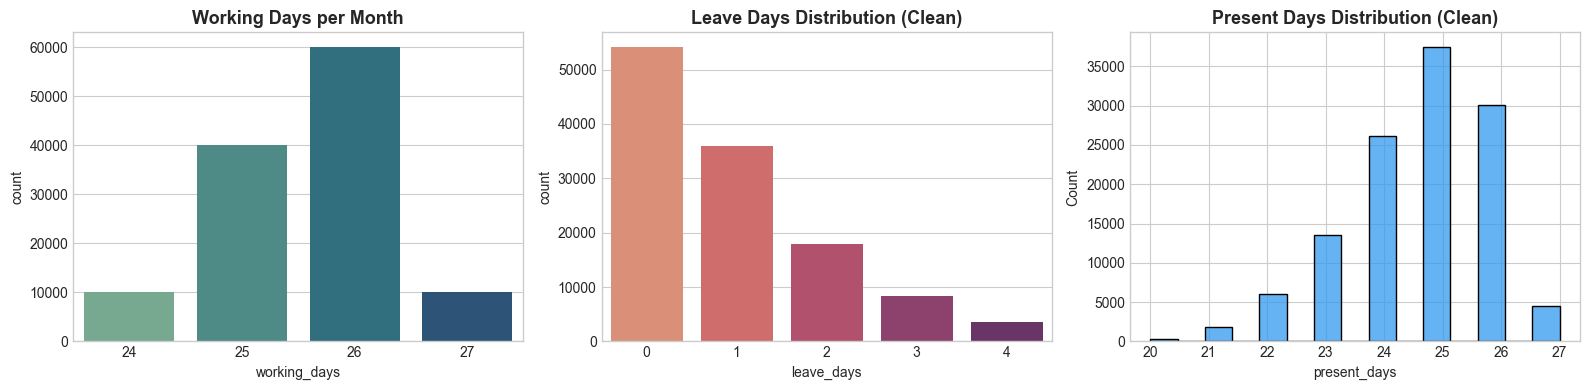

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df_clean, x="working_days", ax=axes[0], palette="crest")
axes[0].set_title("Working Days per Month")

sns.countplot(data=df_clean, x="leave_days", ax=axes[1], palette="flare")
axes[1].set_title("Leave Days Distribution (Clean)")

sns.histplot(df_clean["present_days"], bins=15, ax=axes[2], color="#339af0")
axes[2].set_title("Present Days Distribution (Clean)")

plt.tight_layout()
plt.show()

# Impossible Attendance Check
imp_clean = df_clean[df_clean["present_days"] > df_clean["working_days"]]
imp_anom = df_anom[df_anom["present_days"] > df_anom["working_days"]]
print(f"Impossible Attendance records in Clean dataset     : {len(imp_clean)}")
print(f"Impossible Attendance records in Anomalous dataset : {len(imp_anom)}")
display(imp_anom[["employee_id", "payroll_month", "working_days", "present_days", "leave_days", "anomaly_type"]].head(5))


## 9. Deductions Breakdown (PF, ESI, TDS, Professional Tax)
Analyze the contribution of each statutory deduction component to total deductions.


,count,mean,std,min,25%,50%,75%,max
pf,120000.0,5202.42,4606.07,810.00,2181.95,3670.33,6441.57,38850.38
esi,120000.0,3.02,20.80,0.00,0.00,0.00,0.00,157.48
tds,120000.0,8608.17,14810.22,0.00,814.72,2771.80,9049.52,156635.24
other_deductions,120000.0,200.00,0.00,200.00,200.00,200.00,200.00,200.00
total_deductions,120000.0,14013.61,19352.43,1100.47,3199.27,6646.85,15701.25,194016.40


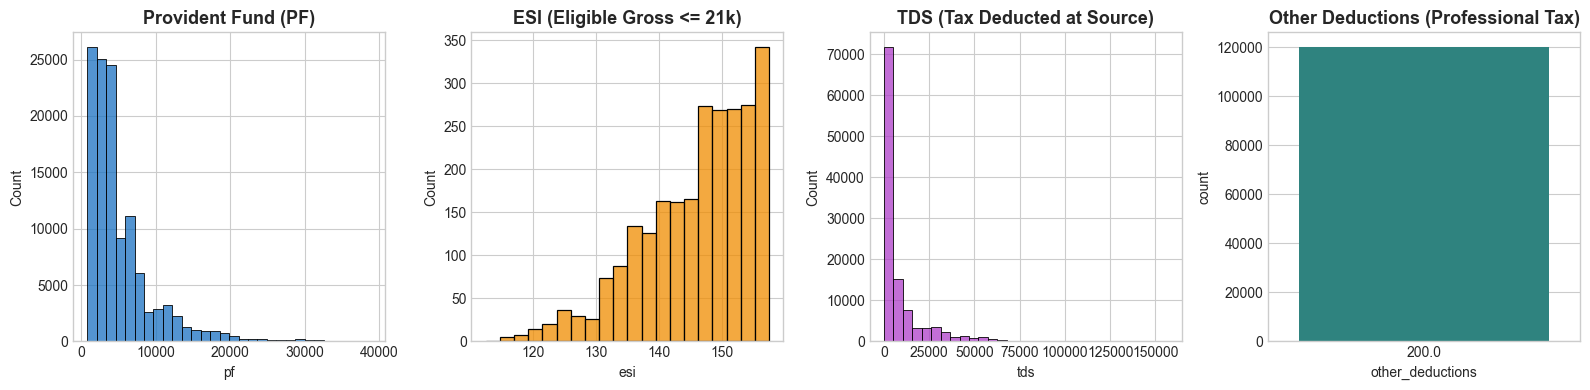

In [9]:
ded_summary = df_clean[["pf", "esi", "tds", "other_deductions", "total_deductions"]].describe().T.round(2)
display(ded_summary)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
sns.histplot(df_clean["pf"], ax=axes[0], color="#1971c2", bins=30)
axes[0].set_title("Provident Fund (PF)")

sns.histplot(df_clean[df_clean["esi"] > 0]["esi"], ax=axes[1], color="#f08c00", bins=20)
axes[1].set_title("ESI (Eligible Gross <= 21k)")

sns.histplot(df_clean[df_clean["tds"] > 0]["tds"], ax=axes[2], color="#ae3ec9", bins=30)
axes[2].set_title("TDS (Tax Deducted at Source)")

sns.countplot(data=df_clean, x="other_deductions", ax=axes[3], palette="viridis")
axes[3].set_title("Other Deductions (Professional Tax)")

plt.tight_layout()
plt.show()


## 10. Mathematical Reconciliation Audit
Audit deterministic payroll reconciliation rules:
1. `gross_salary == basic_salary + allowances + overtime_amount + bonus`
2. `total_deductions == pf + esi + tds + other_deductions`
3. `net_salary == gross_salary - total_deductions`


In [10]:
# Reconciliation checks on clean dataset
gross_diff_clean = np.abs(df_clean["gross_salary"] - (df_clean["basic_salary"] + df_clean["allowances"] + df_clean["overtime_amount"] + df_clean["bonus"]))
ded_diff_clean = np.abs(df_clean["total_deductions"] - (df_clean["pf"] + df_clean["esi"] + df_clean["tds"] + df_clean["other_deductions"]))
net_diff_clean = np.abs(df_clean["net_salary"] - (df_clean["gross_salary"] - df_clean["total_deductions"]))

print(f"Clean Data - Max Gross Discrepancy     : ₹{gross_diff_clean.max():.4f}")
print(f"Clean Data - Max Deductions Discrepancy: ₹{ded_diff_clean.max():.4f}")
print(f"Clean Data - Max Net Discrepancy       : ₹{net_diff_clean.max():.4f}")

# Reconciliation checks on anomalous dataset
net_diff_anom = np.abs(df_anom["net_salary"] - (df_anom["gross_salary"] - df_anom["total_deductions"]))
corrupted_net_records = df_anom[net_diff_anom > 0.1]
print(f"\nAnomalous Data - Records failing Net Reconciliation: {len(corrupted_net_records):,} (Injected ABNORMAL_NET_SALARY anomalies)")
display(corrupted_net_records[["employee_id", "payroll_month", "gross_salary", "total_deductions", "net_salary", "anomaly_type"]].head(5))


Clean Data - Max Gross Discrepancy     : ₹0.0000
Clean Data - Max Deductions Discrepancy: ₹0.0000
Clean Data - Max Net Discrepancy       : ₹0.0000
Anomalous Data - Records failing Net Reconciliation: 519 (Injected ABNORMAL_NET_SALARY anomalies)


,employee_id,payroll_month,gross_salary,total_deductions,net_salary,anomaly_type
240,EMP000241,2024-01,40164.38,3127.10,19037.28,ABNORMAL_NET_SALARY
721,EMP000726,2024-01,539324.01,121771.64,442552.37,ABNORMAL_NET_SALARY
1085,EMP001091,2024-01,122887.86,16102.45,131785.41,ABNORMAL_NET_SALARY
1219,EMP001225,2024-01,27153.69,28330.98,0.00,ABNORMAL_DEDUCTION
1397,EMP001404,2024-01,30015.97,32302.21,0.00,ABNORMAL_DEDUCTION


## 11. Month-over-Month Salary Progression & Increment Dynamics
Analyze how employee salaries evolve over 12 months, highlighting legitimate annual increments (~5-15%) and promotions (~15-30%).


Total legitimate increment events across 10,000 employees over 12 months: 9,152
Average annual increment rate: 11.16%


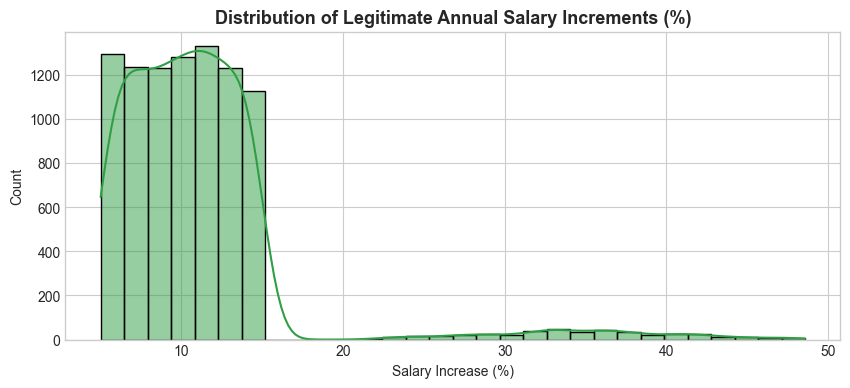

In [11]:
df_sorted = df_clean.sort_values(by=["employee_id", "payroll_month"]).copy()
df_sorted["prev_basic"] = df_sorted.groupby("employee_id")["basic_salary"].shift(1)
df_sorted["basic_change_pct"] = ((df_sorted["basic_salary"] - df_sorted["prev_basic"]) / df_sorted["prev_basic"]) * 100.0

legitimate_increments = df_sorted[df_sorted["basic_change_pct"] > 0]["basic_change_pct"]

plt.figure(figsize=(10, 4))
sns.histplot(legitimate_increments, bins=30, kde=True, color="#2f9e44")
plt.title("Distribution of Legitimate Annual Salary Increments (%)")
plt.xlabel("Salary Increase (%)")
plt.show()

print(f"Total legitimate increment events across 10,000 employees over 12 months: {len(legitimate_increments):,}")
print(f"Average annual increment rate: {legitimate_increments.mean():.2f}%")


## 12. Anomaly Class Distribution
Inspect the distribution of normal (`is_anomaly = 0`) vs anomalous (`is_anomaly = 1`) records.


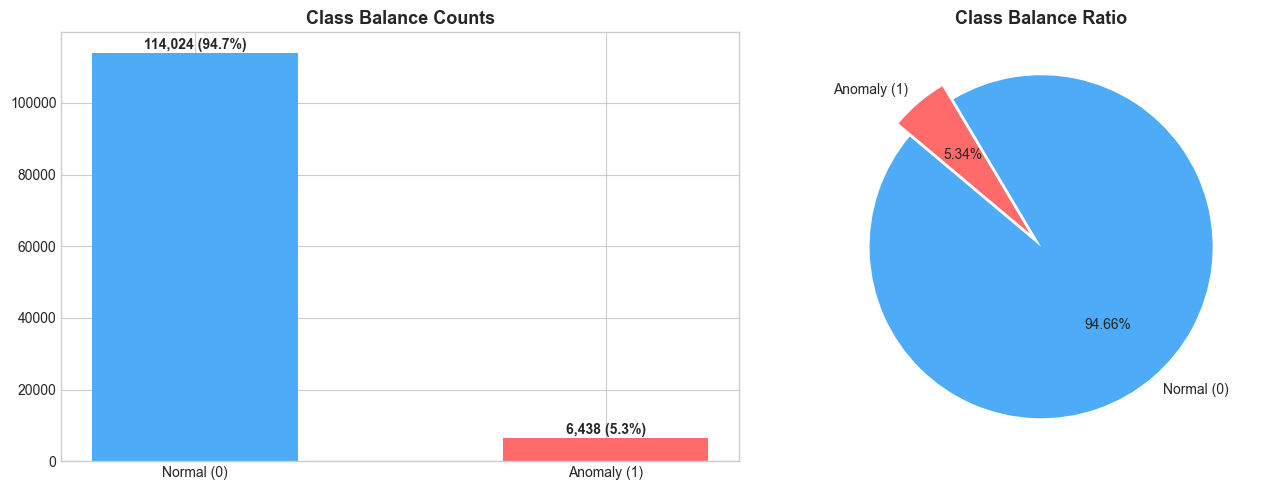

In [12]:
counts = df_anom["is_anomaly"].value_counts()
labels = ["Normal (0)", "Anomaly (1)"]
colors = ["#4dabf7", "#ff6b6b"]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].bar(labels, counts.values, color=colors, width=0.5)
ax[0].set_title("Class Balance Counts")
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 1000, f"{v:,} ({v/len(df_anom)*100:.1f}%)", ha="center", fontweight="bold")

ax[1].pie(counts.values, labels=labels, autopct="%1.2f%%", startangle=140, colors=colors, explode=(0, 0.1))
ax[1].set_title("Class Balance Ratio")

plt.tight_layout()
plt.show()


## 13. Breakdown of 13 Injected Anomaly Types
Examine the occurrence of each anomaly type, breakdown by severity rating (CRITICAL, HIGH, MEDIUM, LOW), and review the audit trail.


Sample Anomaly Audit Log Entries:


,Severity Rating,Count,Percentage
0,CRITICAL,2769,46.15
1,HIGH,2308,38.47
2,MEDIUM,923,15.38


,anomaly_id,employee_id,payroll_month,anomaly_type,severity,original_value,modified_value,description
0,ANOM_000001,EMP006305,2024-01,SUDDEN_SALARY_INCREASE,HIGH,Basic=44444.14,Basic=89989.27,Sudden unauthorized salary spike of 2.0x without legitimate promotion record.
1,ANOM_000002,EMP000606,2024-11,SUDDEN_SALARY_INCREASE,HIGH,Basic=23755.82,Basic=48324.49,Sudden unauthorized salary spike of 2.0x without legitimate promotion record.
2,ANOM_000003,EMP003766,2024-04,SUDDEN_SALARY_INCREASE,HIGH,Basic=33427.72,Basic=59358.14,Sudden unauthorized salary spike of 1.8x without legitimate promotion record.
3,ANOM_000004,EMP008778,2024-06,SUDDEN_SALARY_INCREASE,HIGH,Basic=21990.74,Basic=47814.09,Sudden unauthorized salary spike of 2.2x without legitimate promotion record.
4,ANOM_000005,EMP007486,2024-04,SUDDEN_SALARY_INCREASE,HIGH,Basic=11500.43,Basic=23798.74,Sudden unauthorized salary spike of 2.1x without legitimate promotion record.
5,ANOM_000006,EMP008359,2024-04,SUDDEN_SALARY_INCREASE,HIGH,Basic=17653.73,Basic=43860.83,Sudden unauthorized salary spike of 2.5x without legitimate promotion record.
6,ANOM_000007,EMP001427,2024-04,SUDDEN_SALARY_INCREASE,HIGH,Basic=99268.89,Basic=228085.66,Sudden unauthorized salary spike of 2.3x without legitimate promotion record.
7,ANOM_000008,EMP004178,2024-05,SUDDEN_SALARY_INCREASE,HIGH,Basic=34409.98,Basic=68627.86,Sudden unauthorized salary spike of 2.0x without legitimate promotion record.
8,ANOM_000009,EMP003576,2024-06,SUDDEN_SALARY_INCREASE,HIGH,Basic=53751.82,Basic=129031.84,Sudden unauthorized salary spike of 2.4x without legitimate promotion record.
9,ANOM_000010,EMP005886,2024-08,SUDDEN_SALARY_INCREASE,HIGH,Basic=56616.01,Basic=137706.44,Sudden unauthorized salary spike of 2.4x without legitimate promotion record.


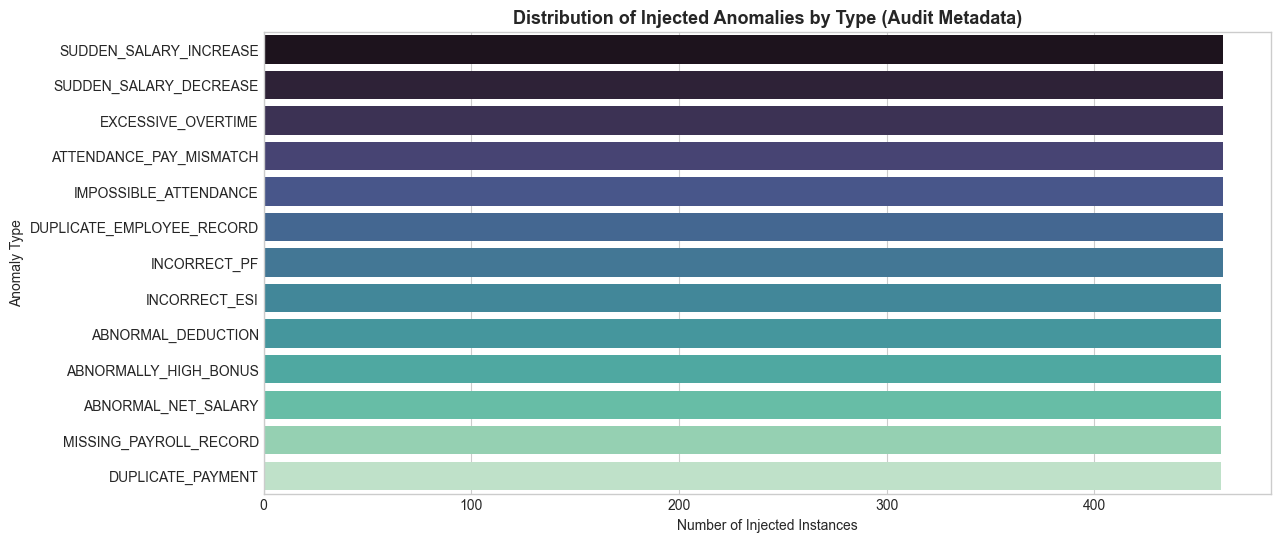

In [13]:
plt.figure(figsize=(13, 6))
type_counts = df_meta["anomaly_type"].value_counts()
sns.barplot(x=type_counts.values, y=type_counts.index, palette="mako")
plt.title("Distribution of Injected Anomalies by Type (Audit Metadata)")
plt.xlabel("Number of Injected Instances")
plt.ylabel("Anomaly Type")
plt.show()

severity_counts = df_meta["severity"].value_counts()
display(pd.DataFrame({
    "Severity Rating": severity_counts.index,
    "Count": severity_counts.values,
    "Percentage": (severity_counts.values / len(df_meta) * 100).round(2)
}))

print("\nSample Anomaly Audit Log Entries:")
display(df_meta.head(10))


## 14. Deep-Dive Case Studies: Anomalous vs Normal Employees
Let's inspect the complete 12-month timeline for sample employees with injected anomalies.


In [14]:
# Case Study 1: Sudden Salary Spike Anomaly
sample_anom = df_meta[df_meta["anomaly_type"] == "SUDDEN_SALARY_INCREASE"].iloc[0]
emp_case_1 = sample_anom["employee_id"]
print(f"=== Case 1: SUDDEN_SALARY_INCREASE on Employee {emp_case_1} in Month {sample_anom['payroll_month']} ===")
emp_1_history = df_anom[df_anom["employee_id"] == emp_case_1][["payroll_month", "basic_salary", "gross_salary", "net_salary", "is_anomaly", "anomaly_type"]]
display(emp_1_history)

# Case Study 2: Excessive Overtime Anomaly
sample_anom_ot = df_meta[df_meta["anomaly_type"] == "EXCESSIVE_OVERTIME"].iloc[0]
emp_case_2 = sample_anom_ot["employee_id"]
print(f"\n=== Case 2: EXCESSIVE_OVERTIME on Employee {emp_case_2} in Month {sample_anom_ot['payroll_month']} ===")
emp_2_history = df_anom[df_anom["employee_id"] == emp_case_2][["payroll_month", "overtime_hours", "overtime_amount", "gross_salary", "is_anomaly", "anomaly_type"]]
display(emp_2_history)


=== Case 1: SUDDEN_SALARY_INCREASE on Employee EMP006305 in Month 2024-01 ===
=== Case 2: EXCESSIVE_OVERTIME on Employee EMP009166 in Month 2024-06 ===


,payroll_month,basic_salary,gross_salary,net_salary,is_anomaly,anomaly_type
6284,2024-01,89989.27,145463.72,134105.23,1,SUDDEN_SALARY_INCREASE
16242,2024-02,44444.14,98764.75,87521.64,0,NONE
26195,2024-03,44444.14,103027.54,91206.78,0,NONE
36154,2024-04,44444.14,99731.41,88391.64,0,NONE
46116,2024-05,44444.14,98764.75,87521.64,0,NONE
56077,2024-06,44444.14,102131.39,90445.05,0,NONE
66037,2024-07,44444.14,98764.75,87521.64,0,NONE
76001,2024-08,44444.14,98764.75,87521.64,0,NONE
85969,2024-09,44444.14,101598.06,89991.72,0,NONE
95929,2024-10,48038.60,106752.44,93941.61,0,NONE


,payroll_month,overtime_hours,overtime_amount,gross_salary,is_anomaly,anomaly_type
9135,2024-01,0.0,0.00,58921.51,0,NONE
19087,2024-02,0.0,0.00,58921.51,0,NONE
29048,2024-03,0.0,0.00,58921.51,0,NONE
39008,2024-04,0.0,0.00,58921.51,0,NONE
48968,2024-05,2.7,516.27,59437.78,0,NONE
58928,2024-06,91.4,18175.81,77097.32,1,EXCESSIVE_OVERTIME
68889,2024-07,19.8,3645.77,62567.28,0,NONE
78850,2024-08,0.0,0.00,58921.51,0,NONE
88816,2024-09,0.0,0.00,58921.51,0,NONE
98781,2024-10,0.0,0.00,58921.51,0,NONE


## 15. Key Takeaways & Transition to Phase 2

### Summary of Findings:
1. **Clean Foundation**: The clean dataset of 10,000 employees over 12 months (120,000 records) is 100% mathematically reconciled, adheres to department salary tiers, and exhibits realistic attendance and increment dynamics.
2. **Controlled Anomaly Injection**: 13 distinct anomaly categories were injected into a separate dataset (`anomalous_payroll.csv`), creating a realistic 5.34% anomaly rate with an exact audit trail in `anomaly_metadata.csv`.
3. **Deterministic Validation**: Core structural errors (impossible attendance, duplicate disbursements, reconciliation failures) are reliably caught by deterministic rules, establishing a benchmark against which ML models can complement detection.
4. **ML Feature Foundation**: 66 engineered features (ratios, MoM deltas, historical rolling statistics, and peer comparisons) have been implemented and verified.

### Next Step:
👉 **PHASE 2 — Feature Engineering, Label Quality & Training Dataset Preparation**.
